In [1]:

import glob
import os
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss, mean_squared_error
from sklearn.model_selection import GroupKFold, LeaveOneGroupOut, StratifiedKFold
from sklearn.preprocessing import StandardScaler



# Methods



In [2]:

def reshape_tfr(tfr, bin_width):
    """Bin a 4D TFR array over time and flatten channels x frequencies as features."""
    ntrials, nchannels, nfreqs, ntimes = tfr.shape
    nbins = ntimes // bin_width
    if nbins == 0:
        raise ValueError(f"bin_width ({bin_width}) must be <= ntimes ({ntimes}).")

    valid_times = nbins * bin_width
    X = tfr[..., :valid_times]
    X_binned = X.reshape(ntrials, nchannels, nfreqs, nbins, bin_width).mean(axis=-1)
    X_transposed = np.transpose(X_binned, (0, 3, 1, 2))  # ntrials, nbins, nchannels, nfreqs
    X_reshaped = X_transposed.reshape(ntrials * nbins, nchannels * nfreqs)

    Y = np.tile(np.arange(nbins), ntrials)
    return X_reshaped, Y



In [3]:
def prep_feature_single_session(beh_path, event_path, iti_path, iti_threshold=500, bin_width=500, include_iti=True):
    """Load one session and return features, time-bin labels, and trial groups."""
    df = pd.read_csv(beh_path)
    correct_mask = df.TOJ_res == 1
    iti_mask = np.logical_and(correct_mask, df.ITI > iti_threshold)
    
    event_tfr = np.load(event_path, allow_pickle=True)['data']
    iti_tfr = np.load(iti_path, allow_pickle=True)['data']
    
    tfr_pos = event_tfr[correct_mask]
    tfr_neg = iti_tfr[iti_mask]
    
    tid_pos = df[correct_mask].index.values
    tid_neg = df[iti_mask].index.values
    
    del event_tfr, iti_tfr 
    
    X_pos, y_pos = reshape_tfr(tfr_pos, bin_width=bin_width)
    nbins_pos = y_pos.shape[0] // len(tid_pos)
    g_pos = np.repeat(tid_pos, nbins_pos) 
    
    if include_iti: # Optionally include ITI as negative samples
        X_neg, y_neg = reshape_tfr(tfr_neg, bin_width=bin_width)
        y_neg[:] = -1 
        nbins_neg = y_neg.shape[0] // len(tid_neg)
        g_neg = np.repeat(tid_neg, nbins_neg)
        
        X_session = np.concatenate([X_pos, X_neg], axis=0)
        Y_session = np.concatenate([y_pos, y_neg], axis=0)
        g_session = np.concatenate([g_pos, g_neg], axis=0) # tracking trial indices
        
        return X_session, Y_session, g_session
    else:
        return X_pos, y_pos, g_pos
        
    

def prep_feature(subject_path, subject_id, bin_width, event_name='Movie', iti_threshold=500, include_iti=True):
    """Concatenate session-level features for one subject/event."""
    beh_dir = subject_path / "Beh"
    event_dir = subject_path / "Epoch" / event_name
    iti_dir = subject_path / "Epoch" / "ITI"

    event_files = glob.glob(str(event_dir / f"{subject_id}_Session*_{event_name}_tfr.npz"))

    X, Y, G_trial, G_session = [], [], [], []
    for event_fn in event_files:
        match = re.search(r'Session(\d+)', os.path.basename(event_fn))
        if not match:
            continue
            
        session_num = int(match.group(1))
        iti_fn = iti_dir / f"{subject_id}_Session{session_num}_ITI_tfr.npz"
        beh_search = str(beh_dir / f"{subject_id}_*_Session{session_num}.csv")
        beh_files = glob.glob(beh_search)
        
        # Check files exist
        assert len(beh_files) == 1, f"Expected 1 behavioral file for session {session_num}, found {len(beh_files)}"
        if include_iti:
            assert iti_fn.exists(), f"ITI file not found: {iti_fn}"
            
        beh_fn = beh_files[0]
        
        x, y, g_trial = prep_feature_single_session(
                beh_path=beh_fn,
                event_path=event_fn,
                iti_path=iti_fn,
                bin_width=bin_width,
                iti_threshold=iti_threshold,
                include_iti=include_iti
            )
        g_session = int(session_num) * np.ones_like(g_trial)
        
        X.append(x)
        Y.append(y)
        G_trial.append(g_trial)
        G_session.append(g_session)

    X = np.concatenate(X, axis=0)
    Y = np.concatenate(Y, axis=0)
    G_trial = np.concatenate(G_trial, axis=0)
    G_session = np.concatenate(G_session, axis=0)  

    return X, Y, G_trial, G_session



In [4]:
def train_ovr_models(x_train, y_train, x_test, y_test, C, penalty='l1', neg_label=-1, **kwargs):
    """Train one-vs-rest logistic models and score positive held-out samples."""
    # Isolate positive test samples for evaluation
    pos_mask = y_test != neg_label
    pos_x, pos_y = x_test[pos_mask], y_test[pos_mask] 
    
    pos_labels = np.unique(y_train[y_train != neg_label])
    
    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train)
    pos_x_scaled = scaler.transform(pos_x) 
    
    pred_probas = []
    for _label in pos_labels:
        ovr_label = (y_train == _label).astype(int)
        
        clf = LogisticRegression(C=C, penalty=penalty, **kwargs)
        clf.fit(x_train_scaled, ovr_label)
        
        pos_prob = clf.predict_proba(pos_x_scaled)[:, 1] 
        pred_probas.append(pos_prob)
    
    pred_probas = np.array(pred_probas)
    pred_probas /= pred_probas.sum(axis=0)
    
    y_pred_indices = np.argmax(pred_probas, axis=0)
    y_pred = pos_labels[y_pred_indices]
    
    nll = -log_loss(pos_y, pred_probas.T) 
    rmse = np.sqrt(mean_squared_error(pos_y, y_pred))
    acc = accuracy_score(pos_y, y_pred)
    
    return dict(C=C, neg_log_loss=nll, rmse=rmse, accuracy=acc)

def run_nest_CV(X, y, inner_cv, outer_cv, groups=None, 
                scoring='neg_log_loss', # 'neg_log_loss' | 'rmse' | 'accuracy' 
                direction='maximize', # 'maximize' | 'minimize' (when using 'rmse')
                n_iters=100, 
                lr_kwargs=None, 
                hyper_kwargs=None):
    
    # Merge default kwargs with user inputs
    default_hyper = dict(show_progress_bar=False, n_jobs=-1, gc_after_trial=True)
    default_lr = dict(solver='liblinear', random_state=42, class_weight='balanced', penalty='l1')
    
    hyper_kwargs = {**default_hyper, **(hyper_kwargs or {})}
    lr_kwargs = {**default_lr, **(lr_kwargs or {})}
        
    def objective(trial, x_in, y_in, cv, metric, groups_in=None, **kw):
        C = trial.suggest_float('C', 1e-4, 1e+2, log=True)
        cv_score = []
        
        # Inner split
        for train_idx, test_idx in cv.split(x_in, y_in, groups=groups_in):
            x_tr, x_te = x_in[train_idx], x_in[test_idx]
            y_tr, y_te = y_in[train_idx], y_in[test_idx]
            
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                performance = train_ovr_models(x_tr, y_tr, x_te, y_te, C=C, **kw)
            cv_score.append(performance[metric])
            
        return np.mean(cv_score)
    
    train_history = list()

    # Outer split
    for train_idx, test_idx in outer_cv.split(X, y, groups=groups):
        X_train, X_test = X[train_idx], X[test_idx]
        Y_train, Y_test = y[train_idx], y[test_idx]
        
        G_train = groups[train_idx] if groups is not None else None
        
        optuna.logging.set_verbosity(optuna.logging.ERROR)
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            study = optuna.create_study(direction=direction)
            
            study.optimize(
                lambda trial: objective(trial, X_train, Y_train, cv=inner_cv, metric=scoring, groups_in=G_train, **lr_kwargs), 
                n_trials=n_iters, 
                **hyper_kwargs
            )
        
        best_c = study.best_params.get('C')
        
        # Evaluate the best model on the held-out test fold
        score_dict = train_ovr_models(X_train, Y_train, X_test, Y_test, C=best_c, **lr_kwargs)
        train_history.append(score_dict)
        
    return train_history



In [5]:
def shuffle_within_trials(y, groups, seed, neg_label=-1):
    """
    Shuffles positive class labels independently within each trial/group.
    Preserves the exact class distribution per trial while destroying 
    the relationship between the features and the labels.
    """
    rng = np.random.RandomState(seed)
    y_perm = y.copy()
    
    # Isolate each trial and shuffle its labels internally
    for g in np.unique(groups):
        pos_mask = (groups == g) & (y != neg_label)
        pos_labels = y[pos_mask]
        
        y_perm[pos_mask] = rng.permutation(pos_labels)
        
    return y_perm

def run_adaptive_permutation(X, Y, G, 
                             observed_score,
                             inner_cv, outer_cv,
                             groups=None,
                             neg_label=-1,
                             max_permutations=200, alpha=0.05,
                             direction='maximize', scoring='neg_log_loss', n_iters=100,
                             lr_kws=None, hyper_kws=None):
    
    """
    Executes an adaptive permutation test to evaluate the statistical significance 
    of a nested cross-validation decoding pipeline, using early stopping to 
    save compute time on non-significant subjects.

    Parameters
    ----------
    X : np.ndarray
        Feature matrix of shape (nsamples, nfeatures), containing neural data.
    Y : np.ndarray
        Target labels of shape (nsamples,).
    G : np.ndarray
        Group labels tracking trial indices of shape (nsamples,). 
        Used to ensure shuffling occurs within trials.
    observed_score : float
        The true performance metric obtained from the unpermuted dataset.
    inner_cv : BaseCrossValidator
        Instantiated scikit-learn cross-validator for the inner hyperparameter tuning loop.
    outer_cv : BaseCrossValidator
        Instantiated scikit-learn cross-validator for the outer evaluation loop.
    groups : np.ndarray, optional
        Group labels used specifically for the cross-validation splits 
        (e.g., session IDs or trial IDs to prevent leakage). 
        Defaults to None.
    neg_label : int, optional
        The label denoting negative/baseline samples (e.g., ITI data) that must NOT be shuffled. 
        Defaults to -1.
    max_permutations : int, optional
        The maximum number of permutation iterations to run. 
        Defaults to 200.
    alpha : float, optional
        The significance threshold (p-value boundary). 
        Used to calculate the early-stopping threshold. Defaults to 0.05.
    direction : str, optional
        Whether the metric should be maximized ('maximize', e.g., accuracy) 
        or minimized ('minimize', e.g., rmse). 
        Defaults to 'maximize'.
    scoring : 'neg_log_loss' | 'accuracy' | 'rmse'
        The key used to extract the relevant metric from the nested CV performance dictionary.
        Defaults to 'neg_log_loss'.
    n_iters : int, optional
        The number of Optuna trials to run inside the nested CV. 
        Defaults to 100.
    lr_kws : dict, optional
        Keyword arguments passed to the LogisticRegression model.
    hyper_kws : dict, optional
        Keyword arguments passed to the Optuna study optimizer.

    Returns
    -------
    dict
        A dictionary containing the permutation test results:
        - 'passed' (bool): True if the subject passed the significance threshold.
        - 'p_value' (float): The empirical p-value (may be an upper bound if stopped early).
        - 'null_scores' (list): The list of scores obtained from the permuted runs.
    """
    
    failing_threshold = int(np.floor(alpha * max_permutations))
    
    n_failed = 0
    seed = 0
    null_scores = list()
    
    while n_failed < failing_threshold and seed < max_permutations:
        y_perm = shuffle_within_trials(Y, G, seed, neg_label=neg_label)
        
        train_history = run_nest_CV(X, y_perm, inner_cv, outer_cv, groups,
                direction=direction,
                scoring=scoring, 
                n_iters=n_iters)
        score = np.mean([fold[scoring] for fold in train_history])
        null_scores.append(score)
        
        if direction == 'maximize' and score >= observed_score:
            n_failed += 1
        elif direction == 'minimize' and score <= observed_score:
            n_failed += 1

        if n_failed == failing_threshold:
            break
        
        seed += 1
        
    p_value = n_failed / (seed + 1) # 'seed' starts from 0
    
    return dict(
        passed=(n_failed < failing_threshold),
        p_value=p_value,
        null_scores=null_scores
    )

In [6]:
def cross_stage_validation(X_enc, X_ret, Y_enc, Y_ret, Cs_enc, Cs_ret, cv, groups=None, **kwargs):
    """Train on encoding/rest folds and evaluate within and across stages."""
    
    assert X_ret.shape == X_enc.shape, f"Expected same shape of data, X_enc: {X_enc.shape}, X_ret: {X_ret.shape}" 
    
    default_kws = dict(solver='liblinear', random_state=42, class_weight='balanced', penalty='l1', neg_label=-1)
    kws = {**default_kws, **(kwargs or {})}
    
    perf_df = list()
    for fold, (train_idx, test_idx) in enumerate(cv.split(X_enc, Y_enc, groups=groups)): # 
        C_enc, C_ret = Cs_enc[fold], Cs_ret[fold]
        
        x_tr_enc, x_te_enc = X_enc[train_idx], X_enc[test_idx]
        y_tr_enc, y_te_enc = Y_enc[train_idx], Y_enc[test_idx]
        
        x_tr_ret, x_te_ret = X_ret[train_idx], X_ret[test_idx]
        y_tr_ret, y_te_ret = Y_ret[train_idx], Y_ret[test_idx]
        
        for x_tr, y_tr, C, stage_tr in zip([x_tr_enc, x_tr_ret], [y_tr_enc, y_tr_ret] , [C_enc, C_ret], ['Enc', 'Ret']):
            for x_te, y_te, stage_te in zip([x_te_enc, x_te_ret],[y_te_enc, y_te_ret], ['Enc', 'Ret']):
                perf = train_ovr_models(x_tr, y_tr, x_te, y_te, C, **kws)
                perf['Train_Stage'], perf['Test_Stage'] = stage_tr, stage_te
                
                perf_df.append(perf)
    
    perf_df = pd.DataFrame.from_dict(perf_df)
    summary_df = perf_df.pivot_table(
        index=['Train_Stage', 'Test_Stage'], 
        values=['neg_log_loss', 'rmse', 'accuracy'], 
        aggfunc='mean'
    ).reset_index(drop=False)

    return summary_df



In [7]:
def zscore_across_channels_per_freq(X, nfreqs=10):
    """
    Z-score X across channels, separately for each frequency band, per trial.

    Parameters
    ----------
    X : ndarray of shape (n_samples, n_features)
        The input data. Assumes shape (ntrials, nchannels * nfreqs).

    nfreqs : int
        Number of frequency bands.

    Returns
    -------
    X_out : ndarray of shape (n_samples, n_features)
        Z-scored version of X.
    """
    

    nsamples, nfeatures = X.shape
    nchannels = nfeatures // nfreqs

    X_reshape = X.reshape(nsamples, nchannels, nfreqs)
    Xz = stats.zscore(X_reshape, axis=1)
    
    X_out = Xz.reshape(nsamples, nfeatures)
    
    return X_out

def create_ablation_mask(nfeatures, drop_indices, nfreqs=10, axis=1):
    """Return a boolean feature mask after dropping channels or frequencies."""
    
    if np.isscalar(drop_indices):
        drop_indices = [drop_indices]
    
    nchannels = nfeatures // nfreqs    
    mask_2d = np.ones((nchannels, nfreqs), dtype=bool)
    
    if axis == 0:
        # Ablate specific channels across all frequencies
        for idx in drop_indices:
            mask_2d[idx, :] = False
    elif axis == 1:
        # Ablate specific frequencies across all channels
        for idx in drop_indices:
            mask_2d[:, idx] = False
    else:
        raise ValueError("axis must be 0 (channels) or 1 (frequencies)")

    return mask_2d.flatten()



In [8]:
def extract_ovr_weights(X, y, C, penalty='l1', neg_label=-1, **kwargs):
    """
    Refits the OvR models on the entire training set and extracts 
    the raw math parameters (weights, biases, and scaler info) for easy saving.
    """
    default_kws = dict(solver='liblinear', random_state=42, class_weight='balanced')
    kws = {**default_kws, **(kwargs or {})}
    
    pos_labels = np.unique(y[y != neg_label])
    n_classes = len(pos_labels)
    n_features = X.shape[1]
    
    # 1. Fit the scaler and extract parameters
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    mu = scaler.mean_
    sigma = scaler.scale_
    
    # Initialize arrays for weights (W) and biases (B)
    W = np.zeros((n_classes, n_features))
    B = np.zeros(n_classes)
    
    # 2. Train OvR models and extract raw parameters
    for i, label in enumerate(pos_labels):
        ovr_label = (y == label).astype(int)
        
        clf = LogisticRegression(C=C, penalty=penalty, **kws)
        clf.fit(X_scaled, ovr_label)
        
        W[i, :] = clf.coef_[0]
        B[i] = clf.intercept_[0]
        
    # Return as a simple dictionary that can be easily saved with np.savez
    model_params = {
        'W': W,                 # Shape: (n_classes, n_features)
        'B': B,                 # Shape: (n_classes,)
        'mu': mu,               # Shape: (n_features,)
        'sigma': sigma,         # Shape: (n_features,)
        'classes': pos_labels   # Shape: (n_classes,)
    }
    
    return model_params

def apply_ovr_to_4d(X_4d, model_params):
    """
    Applies the extracted OvR weights directly to a 4D array using matrix multiplication.
    
    Parameters:
    -----------
    X_4d : np.ndarray
        The resting state data of shape (ntrials, nchannels, nfreqs, npoints).
    model_params : dict
        The extracted weights dictionary from `extract_ovr_weights`.
        
    Returns:
    --------
    P_out : np.ndarray
        The predicted probabilities of shape (nclasses, ntrials, npoints).
    """
    
    ntrials, nchannels, nfreqs, npoints = X_4d.shape
    nfeatures = nchannels * nfreqs
    nclasses = len(model_params['classes'])
    
    W = model_params['W']
    B = model_params['B']
    mu = model_params['mu']
    sigma = model_params['sigma']
    

    X_transposed = np.transpose(X_4d, (0, 3, 1, 2)) # (ntrials, npoints, nchannels, nfreqs)
    X_flat = X_transposed.reshape(ntrials * npoints, nfeatures)
    
    X_scaled = (X_flat - mu) / (sigma + 1e-10)
    
    Z = X_scaled @ W.T + B
    
    # Z = np.clip(Z, -500, 500) 
    P = 1 / (1 + np.exp(-Z)) # un-normalized
    
    P_reshaped = P.reshape(ntrials, npoints, nclasses)
    P_out = np.transpose(P_reshaped, (2, 0, 1)) # (nclasses, ntrials, npoints)
    
    return P_out

def predict_probas_refit(subject_path, subject_id, C, bin_width = 500, train_event='Movie', predict_event='Rest', iti_threshold=500, include_iti=True):
    X, y, _, _ = prep_feature(subject_path, subject_id, bin_width, event_name = train_event, iti_threshold=iti_threshold, include_iti=include_iti)
    model_params = extract_ovr_weights(X, y, C=C)
    
    event_dir = subject_path / "Epoch" / predict_event
    event_files = glob.glob(str(event_dir / f"{subject_id}_Session*_{predict_event}_tfr.npz"))
    
    pred_probas = list()
    for fn in event_files:
        tfr = np.load(fn, allow_pickle=True)['data'] # ntrials, nchannel, nfreqs, ntimes
        session_probas = apply_ovr_to_4d(tfr, model_params)
        pred_probas.append(session_probas)
    pred_probas = np.concatenate(pred_probas, axis=1)
    
    return model_params, pred_probas



# Configuration and Main Workflow



In [9]:

# Data and analysis configuration. Defaults preserve the original analysis environment.
base_path = Path(r"E:\sEEG\Exp1\CLC\Re")
subject_id = "CLC"

iti_threshold = 500  # samples
bin_width = 500  # samples
nfreqs = 10
train_event = "Movie"
ret_event = "Rest"
include_iti = True



In [9]:
X, Y, G_trial, G_session = prep_feature(base_path, subject_id, bin_width, event_name=train_event, iti_threshold=iti_threshold, include_iti=include_iti)
G = G_trial + G_session * 40



## Time decoding

In [ ]:
inner_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
outer_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=7777)

# Leave one group out
# inner_splitter = GroupKFold(n_splits=2, shuffle=True, random_state=42) 
# outer_splitter = LeaveOneGroupOut()

In [11]:
train_hist_enc = run_nest_CV(X, Y, inner_cv=inner_splitter, outer_cv=outer_splitter, 
                # groups=G_session, # Leave one group out
                direction='maximize',
                scoring='neg_log_loss', 
                n_iters=10)

In [12]:
mean_acc = np.mean([fold['accuracy'] for fold in train_hist_enc])
mean_loss = np.mean([fold['neg_log_loss'] for fold in train_hist_enc])

## Permutation

In [13]:
perm_history = run_adaptive_permutation(X, Y, G, 
                                        # groups=G_session,
                                        observed_score=mean_acc,
                                        inner_cv=inner_splitter, outer_cv=outer_splitter, 
                                        scoring='accuracy',
                                        n_iters=10,
                                        max_permutations=20, alpha=0.05,
                                        )
H0 = perm_history['passed']
p_value = perm_history['p_value']

## Cross-stage validation

In [14]:
X_ret, Y_ret, _, _ = prep_feature(base_path, subject_id, bin_width, event_name=ret_event, iti_threshold=iti_threshold, include_iti=include_iti)

cross_stage_mask = Y_ret <= np.max(Y) # ensuring same classes
X_ret, Y_ret = X_ret[cross_stage_mask], Y_ret[cross_stage_mask]



In [15]:
train_hist_ret = run_nest_CV(X_ret, Y_ret, inner_cv=inner_splitter, outer_cv=outer_splitter, 
                # groups=G_session, # Leave one group out
                direction='maximize',
                scoring='neg_log_loss', 
                n_iters=10)

In [16]:
Cs_enc = [fold['C'] for fold in train_hist_enc]
Cs_ret = [fold['C'] for fold in train_hist_ret]


perf = cross_stage_validation(X, X_ret, Y, Y_ret, Cs_enc, Cs_ret, outer_splitter)

## Feature normalization

In [17]:
Xz = zscore_across_channels_per_freq(X, nfreqs=10)

train_history = run_nest_CV(Xz, Y, inner_cv=inner_splitter, outer_cv=outer_splitter, 
                # groups=G_session, # Leave one group out
                direction='maximize',
                scoring='neg_log_loss', 
                n_iters=10)

## Feature ablation

In [18]:
freqs = [3, 5, 8, 12, 19, 31, 40, 79, 130, 210]
freq_band_labels = {
    'Delta': [3],
    'Theta': [5],
    'Alpha': [8, 12],
    'Beta': [19, 31],
    'Gamma': [40, 79],
    'High Gamma': [130, 210]
}
feature_drop_indices = {band:[freqs.index(f) for f in fs] for band, fs in freq_band_labels.items()}

In [ ]:
nsamples, nfeatures = X.shape
nchannels = nfeatures // nfreqs

In [21]:
# Frequency bands
gamma_mask = create_ablation_mask(nfeatures, drop_indices=feature_drop_indices.get('Gamma'), nfreqs=nfreqs, axis=1)
X_ablated = X[:, gamma_mask]

# X_ablated = zscore_across_channels_per_freq(X[:, gamma_mask], nfreqs=10)

train_history = run_nest_CV(X_ablated, Y, inner_cv=inner_splitter, outer_cv=outer_splitter, 
                # groups=G_session, # Leave one group out
                direction='maximize',
                scoring='neg_log_loss', 
                n_iters=10)

In [22]:
# Channels
chan_12_mask = create_ablation_mask(nfeatures, drop_indices=12, nfreqs=10, axis=0)
X_ablated = X[:, chan_12_mask]

# X_ablated = zscore_across_channels_per_freq(X[:, chan_12_mask], nfreqs=10)

train_history = run_nest_CV(X_ablated, Y, inner_cv=inner_splitter, outer_cv=outer_splitter, 
                # groups=G_session, # Leave one group out
                direction='maximize',
                scoring='neg_log_loss', 
                n_iters=10)

## Predicted probability

In [10]:

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    refit_log_path = Path(r"E:\sEEG\LOG\Exp1_Time_code_fullset.npz")
    best_models_dict = np.load(refit_log_path, allow_pickle=True)["refit_data"].item()

bestC = best_models_dict[subject_id]["best_params"]
del best_models_dict

# Alternative: choose the best C from the current encoding CV history.
# mean_acc = np.mean([fold["accuracy"] for fold in train_hist_enc])
# bestC = [fold["C"] for fold in train_hist_enc][np.argmax(mean_acc)]



In [ ]:
model_params = extract_ovr_weights(X, Y, C=bestC)
del X, Y

In [ ]:
predict_event = train_event
event_dir = base_path / "Epoch" / predict_event
event_files = glob.glob(str(event_dir / f"{subject_id}_Session*_{predict_event}_tfr.npz"))

pred_probas = list()
for fn in event_files:
    tfr = np.load(fn, allow_pickle=True)['data'] # ntrials, nchannel, nfreqs, ntimes
    session_probas = apply_ovr_to_4d(tfr, model_params)
    pred_probas.append(session_probas)
    del tfr, session_probas
pred_probas = np.concatenate(pred_probas, axis=1)



In [11]:
# OR: one-line function
model_params, pred_probas = predict_probas_refit(base_path, subject_id, C=bestC, train_event=train_event, predict_event=train_event, bin_width=bin_width, iti_threshold=iti_threshold, include_iti=include_iti)



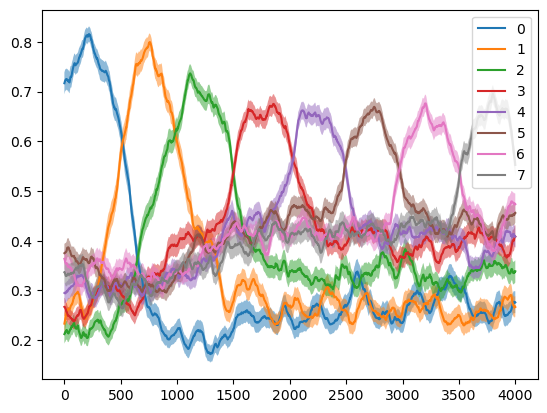

In [12]:
Ts = np.arange(pred_probas.shape[-1])

for s, class_samp in enumerate(pred_probas):
    _u = np.mean(class_samp, axis=0)
    _sem = stats.sem(class_samp, axis=0)
    
    plt.plot(Ts, _u, label=s)
    plt.fill_between(Ts, _u - _sem, _u + _sem,  alpha=0.5)
plt.legend()



In [ ]:
model_params, pred_probas = predict_probas_refit(base_path, subject_id, C=bestC, train_event='Movie', predict_event='Rest', bin_width = bin_width, iti_threshold=iti_threshold, include_iti=True) # one-line function
# np.savez_compressed('', model_params)
# np.savez_compressed('', pred_probas)